## Pretraining on unlabeled data
## Evaluating generative text models

#### using gpt model to generate text


In [7]:
from importlib.metadata import version
import torch
pkgs=["matplotlib","numpy","tiktoken","torch","tensorflow"]
for p in pkgs:
    print(f"{p}:- {version(p)}")

matplotlib:- 3.11.1
numpy:- 2.5.1
tiktoken:- 0.13.0
torch:- 2.13.0
tensorflow:- 2.21.0


In [8]:
from gpt_model import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,      # Vocabulary size
    "context_length": 256,    # Context length
    "emb_dim": 768,           # Embedding dimension
    "n_heads": 12,            # Number of attention heads
    "n_layers": 12,           # Number of layers
    "drop_rate": 0.1,         # Dropout rate
    "qkv_bias": False         # Query-Key-Value bias
}

In [9]:
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
model.eval();

In [10]:
import tiktoken
from gpt_model import generate_text_simple


def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # add batch dimension
    return encoded_tensor

In [11]:
start_context="Hello world , LLM"
tokenizer=tiktoken.get_encoding("gpt2")
token_ids=text_to_token_ids(start_context,tokenizer)
token_ids

tensor([[15496,   995,   837, 27140,    44]])

In [12]:
def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)  # remove batch dimension
    return tokenizer.decode(flat.tolist())


tokens=token_ids_to_text(token_ids, tokenizer)
# 'Every effort moves you'
tokens

'Hello world , LLM'

In [13]:
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"],
)

In [16]:
token_ids.squeeze(0).shape

torch.Size([15])

In [18]:
token_ids_to_text(token_ids,tokenizer) #model not trained 

'Hello world , LLM ongoingeland headache stranded RexAngel infieldcigans admittedly'

### calculating the text generation loss:cross-entropy and perplexity

In [20]:
inputs = torch.tensor([[16833, 3626, 6100],  # ["every effort moves",
                       [40, 1107, 588]]) # "I really like"

targets = torch.tensor([[3626, 6100, 345],  # [" effort moves you",
                        [1107, 588, 11311]])  # " really like chocolate"

In [21]:
with torch.no_grad():
    logits=model(inputs)

In [22]:
logits.shape

torch.Size([2, 3, 50257])

In [25]:
prob=torch.softmax(logits,dim=-1)
print(prob.shape)
prob

torch.Size([2, 3, 50257])


tensor([[[1.8849e-05, 1.5172e-05, 1.1687e-05,  ..., 2.2409e-05,
          6.9776e-06, 1.8776e-05],
         [9.1569e-06, 1.0062e-05, 7.8786e-06,  ..., 2.9090e-05,
          6.0103e-06, 1.3571e-05],
         [2.9877e-05, 8.8507e-06, 1.5741e-05,  ..., 3.5456e-05,
          1.4094e-05, 1.3526e-05]],

        [[1.2561e-05, 2.0538e-05, 1.4332e-05,  ..., 1.0389e-05,
          3.4784e-05, 1.4239e-05],
         [7.2731e-06, 1.7864e-05, 1.0565e-05,  ..., 2.1206e-05,
          1.1390e-05, 1.5559e-05],
         [2.9496e-05, 3.3605e-05, 4.1029e-05,  ..., 6.5249e-06,
          5.8203e-05, 1.3698e-05]]])

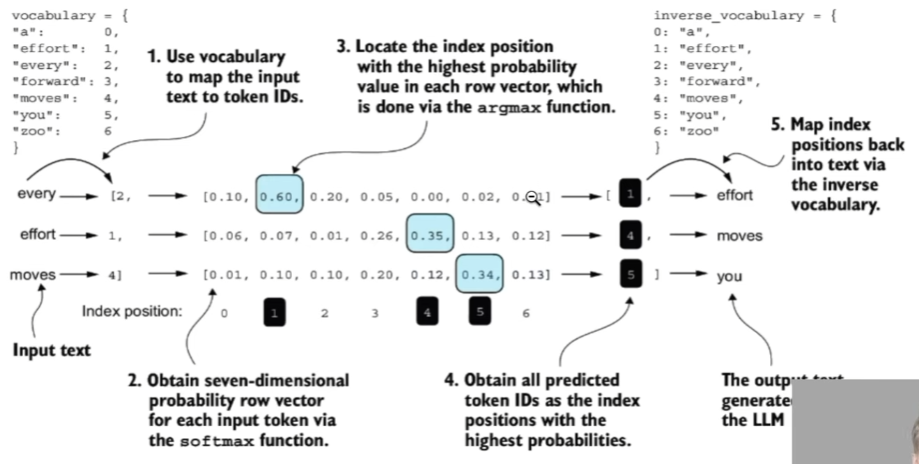




In [27]:
token_ids = torch.argmax(prob, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [28]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [32]:
targets[text_idx]

tensor([ 1107,   588, 11311])

In [30]:
text_idx = 0
target_probas_1 = prob[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

Text 1: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])


In [31]:
text_idx = 1
target_probas_2 = prob[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [33]:
# Compute logarithm of all token probabilities
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [36]:
-1*torch.mean(log_probas)

tensor(10.7940)

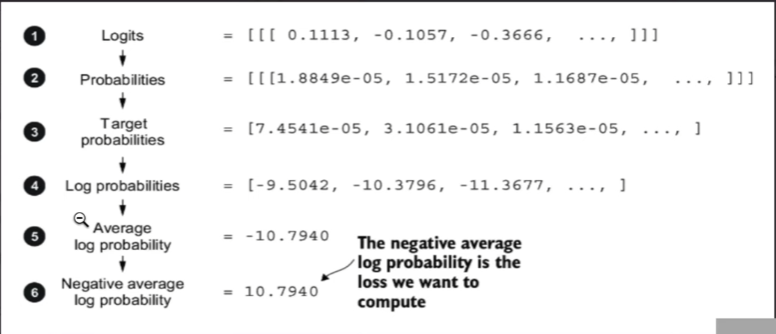

In [44]:
logits.shape

torch.Size([2, 3, 50257])

In [49]:
logits_flatten=logits.flatten(0,1)
logits_flatten.shape

torch.Size([6, 50257])

In [50]:
targets_flatten=targets.flatten()
targets_flatten.shape

torch.Size([6])

In [51]:
torch.nn.functional.cross_entropy(logits_flatten,targets_flatten)

tensor(10.7940)

## Calculating the training and validation loss

In [52]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode("utf-8")
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

In [53]:
text_data[:40]

'I HAD always thought Jack Gisburn rather'

In [54]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [55]:
from gpt_model import create_dataloader_v1
# Alternatively:
# from llms_from_scratch.ch02 import create_dataloader_v1

# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [56]:
torch.manual_seed(123)
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [57]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])


In [58]:
print("Train loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [59]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [62]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches